In [1]:
import torch

In [2]:
torch.finfo(torch.float32).eps

1.1920928955078125e-07

In [3]:
# from google.colab import drive
# drive.mount('../../Drive/MyDrive/GAN/ENCI')

import os

drive_path = r"../../Drive/MyDrive/ENCI"
os.makedirs(drive_path, exist_ok=True)


In [4]:
EPS = torch.finfo(torch.float32).eps

""" GPU """
# Enable CUDA, set tensor type and device
import torch

use_cuda = True
use_cuda = use_cuda and torch.cuda.is_available()
print("CUDA", use_cuda)
if use_cuda:
    dtype = torch.cuda.FloatTensor
    device = torch.device('cuda:0')
else:
    dtype = torch.FloatTensor
    device = torch.device('cpu')


CUDA False


In [5]:
# !mkdir ../../Drive/MyDrive/ENCI\ Drive/aae

from torchvision.ops import nms
print(nms)



<function nms at 0x0000016C2EAF4B80>


In [6]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from torch import autograd
import torch.nn as nn
from torch.utils.data import DataLoader, dataset
from torchvision.datasets import MNIST
import torchvision.transforms as T

from tqdm.notebook import trange
from torchsummary import summary
import argparse
import os
import time


In [7]:
batch_size = 1024
n_classes = 10

In [8]:
train_loader = torch.utils.data.DataLoader(
    MNIST(
        'Data/',
        train=True,
        download=True,
        transform=T.Compose([
                T.transforms.ToTensor(),
                T.Normalize((0.1307,), (0.3081,))  # mean and std deviation of the MNIST dataset
        ])
    ),
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    MNIST(
        'Val/',
        train=False,
        download=True,
        transform=T.Compose([
                T.transforms.ToTensor(),
                T.Normalize((0.1307,), (0.3081,))
        ])
    ),
    batch_size=batch_size,
    shuffle=False
)

In [19]:
supervised = True
dims = 10  #if not supervised else 2  # size of representation layer
Model_dir = '../../Drive/MyDrive/aae/'
Fig_dir = '../../Drive/MyDrive/aae/'

In [10]:
from torch import nn
import torch.nn.functional as F


class Encoder(nn.Module):
    '''Q-net'''
    def __init__(self, dim_input, hidden_dim, dim_z):
        super(Encoder, self).__init__()
        self.dim_input = dim_input  # image size
        self.hidden_dim = hidden_dim
        self.dim_z = dim_z
        self.network = []
        self.network.extend([
            nn.Linear(self.dim_input, self.hidden_dim),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(self.hidden_dim, self.dim_z),
        ])
        self.network = nn.Sequential(*self.network)
    def forward(self, x):
        z = self.network(x)
        return z

class Decoder(nn.Module):
    '''P-net'''
    def __init__(self, dim_input , hidden_dim, dim_z, supervised=False):
        super(Decoder, self).__init__()
        self.dim_input = dim_input
        self.hidden_dim = hidden_dim
        self.dim_z = dim_z
        self.supervised = supervised
        self.network = []
        #input_dim = self.dim_z if not self.supervised else self.dim_z + n_classes
        input_dim = self.dim_z + n_classes   # because supervised=True
        self.network.extend([
            nn.Linear(input_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(self.hidden_dim, self.hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(self.hidden_dim, self.dim_input),
            nn.Sigmoid(),
        ])
        self.network = nn.Sequential(*self.network)
    def forward(self, z):
        x_recon = self.network(z)
        return x_recon

class Discriminator(nn.Module):
    def __init__(self, dims, dim_h):
        super(Discriminator,self).__init__()
        self.dim_z = dims
        self.dim_h = dim_h
        self.network = []
        self.network.extend([
            nn.Linear(self.dim_z, self.dim_h),
            nn.ReLU(),
            nn.Dropout(p=0.2),                         
            nn.Linear(self.dim_h, self.dim_h),
            nn.ReLU(),
            nn.Dropout(p=0.2),                         
            nn.Linear(self.dim_h, 1),
            nn.Sigmoid(),
        ])
        self.network = nn.Sequential(*self.network)

    def forward(self, z):
        disc = self.network(z)
        return disc


In [11]:
def one_hot_encoding(labels, n_classes=10):
    cat = np.array(labels.data.tolist())
    cat = np.eye(n_classes)[cat].astype('float32')
    cat = torch.from_numpy(cat)
    return autograd.Variable(cat)


In [12]:
autoencoder_loss = nn.MSELoss()

def train_validate(
        encoder,
        decoder,
        discriminator,
        dataloader,
        optim_encoder,
        optim_decoder,
        optim_D,
        train
    ):
    total_rec_loss = 0
    total_disc_loss = 0
    total_gen_loss = 0
    if train:
        encoder.train()
        decoder.train()
        discriminator.train()
    else:
        encoder.eval()
        decoder.eval()
        discriminator.eval()

    iteration = 0
    for (data, labels) in dataloader:
        # Reconstruction loss:
        for p in discriminator.parameters():
            p.requires_grad = False

        real_data = autograd.Variable(data).to(device).view(-1, 784)
        encoding = encoder(real_data)

        if decoder.supervised:
            label_hot = one_hot_encoding(labels, n_classes=10).to(device)
            restored_image = decoder(torch.cat((label_hot, encoding), 1))
        else:
            restored_image = decoder(encoding)

        # autoencoder_loss or F.binary_cross_entropy
        reconstruction_loss = autoencoder_loss(restored_image, real_data)
        total_rec_loss += reconstruction_loss.item()
        if train:
            optim_encoder.zero_grad()
            optim_decoder.zero_grad()
            reconstruction_loss.backward()
            optim_encoder.step()
            optim_decoder.step()

        # Discriminator loss:
        # i) latent representation
        encoder.eval()
        z_real_gauss = autograd.Variable(
            torch.randn(data.size()[0], dims)
        ).to(device)
        z_fake_gauss = encoder(real_data)
        # ii) feed into discriminator
        D_real_gauss = discriminator(z_real_gauss)
        D_fake_gauss = discriminator(z_fake_gauss)

        D_loss = -torch.mean(  # cross entropy
            torch.log(D_real_gauss + EPS) +
            torch.log(1 - D_fake_gauss + EPS)
        )
        total_disc_loss += D_loss.item()

        if train:
            optim_D.zero_grad()
            D_loss.backward()
            optim_D.step()

        # Generator (encoder) loss
        if train:
            encoder.train()
        else:
            encoder.eval()
        z_fake_gauss = encoder(real_data)
        D_fake_gauss = discriminator(z_fake_gauss)

        G_loss = -torch.mean(torch.log(D_fake_gauss + EPS))
        total_gen_loss += G_loss.item()

        if train:
            optim_encoder_reg.zero_grad()
            G_loss.backward()
            optim_encoder_reg.step()

        if (iteration % 100) == 0:
            print(
                'reconstruction loss: %.4f, discriminator loss: %.4f, generator loss: %.4f' %
                (reconstruction_loss.item(), D_loss.item(), G_loss.item()))
            
        iteration += 1

    M = len(dataloader.dataset)
    return total_rec_loss / M, total_disc_loss / M, total_gen_loss / M
              

In [13]:
encoder = Encoder(784, 1000, dims).to(device)      
decoder = Decoder(784, 1000, dims, supervised=supervised).to(device)
discriminator = Discriminator(dims, 500).to(device)

In [14]:
lr = 0.00025

In [15]:
#encode/decode optimizers
optim_encoder = torch.optim.Adam(encoder.parameters(), lr=lr)
optim_decoder = torch.optim.Adam(decoder.parameters(), lr=lr)
optim_D = torch.optim.Adam(discriminator.parameters(), lr=lr)
optim_encoder_reg = torch.optim.Adam(encoder.parameters(), lr=lr * 0.1)

In [16]:
n_epochs = 100

In [17]:
train_loss = []
val_loss = []
for epoch in trange(n_epochs):
    l1, l2, l3 = train_validate(
        encoder, decoder, discriminator,
        train_loader, optim_encoder, optim_decoder,
        optim_D, train=True
    )
    print('epoch: {} ---- training loss: {:.8f}'.format(epoch, l1))
    train_loss.append(l1)

    if (epoch % 5) == 0:
        l1, l2, l3 = train_validate(
            encoder, decoder, discriminator,
            val_loader, optim_encoder,
            optim_decoder, optim_D, False
        )
        print('epoch: {} ---- validation loss: {:.8f}'.format(epoch, l1))
        val_loss.append(l1)


  0%|          | 0/100 [00:00<?, ?it/s]

reconstruction loss: 1.2556, discriminator loss: 1.3817, generator loss: 0.6612
epoch: 0 ---- training loss: 0.00085701
reconstruction loss: 0.7735, discriminator loss: 3.3316, generator loss: 0.0835
epoch: 0 ---- validation loss: 0.00080011
reconstruction loss: 0.8050, discriminator loss: 3.4377, generator loss: 0.1624
epoch: 1 ---- training loss: 0.00075778
reconstruction loss: 0.7335, discriminator loss: 2.5332, generator loss: 0.2229
epoch: 2 ---- training loss: 0.00068294
reconstruction loss: 0.6740, discriminator loss: 2.3565, generator loss: 0.2825
epoch: 3 ---- training loss: 0.00063813
reconstruction loss: 0.6421, discriminator loss: 2.4360, generator loss: 0.2938
epoch: 4 ---- training loss: 0.00061291
reconstruction loss: 0.6069, discriminator loss: 2.4110, generator loss: 0.3104
epoch: 5 ---- training loss: 0.00059792
reconstruction loss: 0.5700, discriminator loss: 2.3484, generator loss: 0.2748
epoch: 5 ---- validation loss: 0.00059834
reconstruction loss: 0.6016, discrim

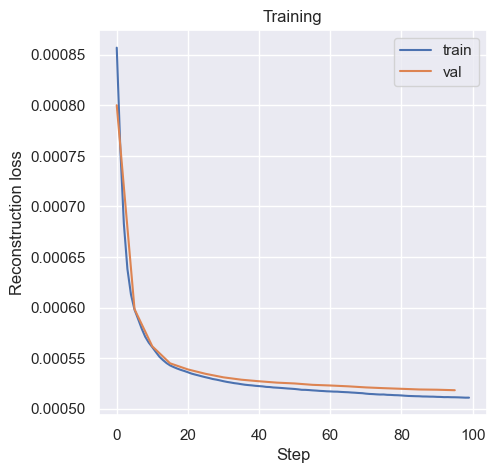

In [21]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

sns.set()
plt.rcParams['figure.figsize'] = 5, 5
plt.plot(np.arange(len(train_loss)), train_loss, label='train')
plt.plot(np.arange(0, len(val_loss) * 5, 5), val_loss, label='val')
plt.title('Training')
plt.xlabel('Step')
plt.ylabel('Reconstruction loss')
plt.legend()
plt.grid(True)
plt.savefig(Fig_dir + 'training_' + str(n_epochs) + 'epochs.png')

In [22]:
from sklearn.manifold import TSNE


def plot_vis(X_enc, y, dims):
    '''Performing t-SNE dimensionality reduction
    and plot in 2 or 3 dimensions.
    '''
    X_tsne = TSNE(n_components=dims).fit_transform(X_enc)
    cmap = plt.get_cmap('rainbow', 10)

    if dims == 2:
        print("IN FOR 2D")
        plt.scatter(
            X_tsne[:, 0], X_tsne[:, 1], 
            c=y, edgecolor='black', cmap=cmap
        )
    else:
        print("IN ELSE FOR 3D")
        fig = plt.figure()
        ax = plt.axes(projection='3d')
        p = ax.scatter3D(
            X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], 
            c=y, cmap=cmap, edgecolor='black'
        )
        fig.colorbar(p, drawedges=True)



In [23]:
# visualization of the unsupervised case
# Does our encoder distinguish the classes?
import math
n_points = 1000

X = []
y = []
for (data, labels) in val_loader:
  images = autograd.Variable(data).to(device).view(-1, 784)
  X.append(encoder(images).cpu().data.numpy())
  y.append(labels.cpu().data.numpy())
  if len(X) * images.shape[0] > n_points:
      break

X = np.concatenate(X, 0)
y = np.concatenate(y, 0)
X = X[:n_points, :]
y = y[:n_points]

print("XSHAPE: ",X.shape)

XSHAPE:  (1000, 10)


In [24]:
print("BEGIN")
X_tsne = TSNE(n_components=3).fit_transform(X)
print("COMPLETE")

BEGIN
COMPLETE


IN FOR 2D


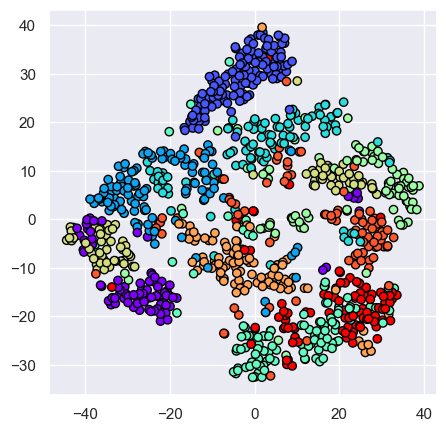

In [25]:
plot_vis(X, y, dims=2)

IN ELSE FOR 3D


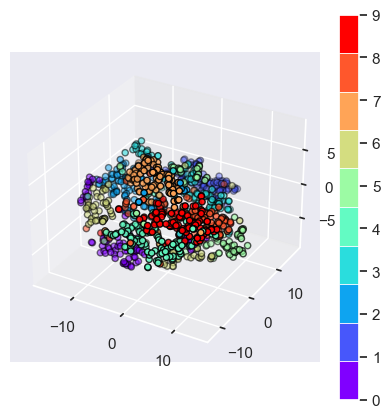

In [26]:
plot_vis(X, y, dims=3)

In [28]:
# visualization of the supervised case
# Does our decoder produce the classes and different styles?

# styles = styles + torch.randn(10, dims).reshape(1, -1).repeat(10, 1).reshape(100, dims)
# numbers = torch.Tensor(np.eye(10)).repeat(10, 1)
# coded = torch.cat([numbers, styles], 1).to(device)
# decoded = decoder(coded).cpu().data.numpy()

# Create 10 style vectors, each 10-dimensional
styles = torch.cat([
    torch.cat([torch.linspace(-3., 3., 5).reshape(5,1),
               torch.zeros(5,9)], dim=1),
    torch.cat([torch.zeros(5,9),
               torch.linspace(-3., 3., 5).reshape(5,1)], dim=1)
], dim=0)


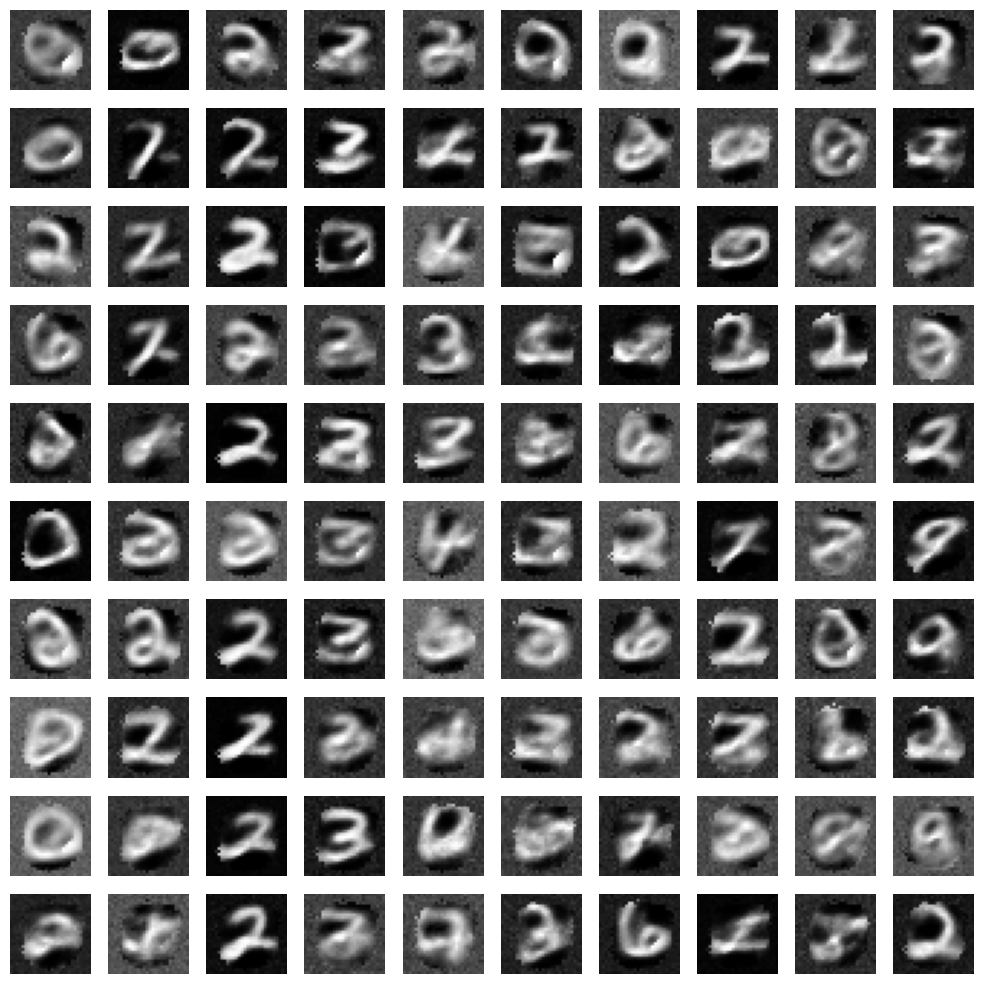

In [29]:
# visualization of the supervised case
# Does our decoder produce the classes and different styles?

import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate latent style vectors
# -----------------------------
# 100 random style vectors (10 classes × 10 samples each)
styles = torch.randn(100, dims)

# -----------------------------
# 2. Generate one-hot class labels
# -----------------------------
# 10 classes, each repeated 10 times → shape (100, 10)
numbers = torch.Tensor(np.eye(10)).repeat(10, 1)

# -----------------------------
# 3. Concatenate labels + styles
# -----------------------------
coded = torch.cat([numbers, styles], dim=1).to(device)

# -----------------------------
# 4. Decode into images
# -----------------------------
decoded = decoder(coded).cpu().data.numpy()

# -----------------------------
# 5. Plot the 100 decoded images in a 10×10 grid
# -----------------------------
fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for i in range(100):
    ax = axes[i // 10, i % 10]
    ax.imshow(decoded[i].reshape(28, 28), cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()


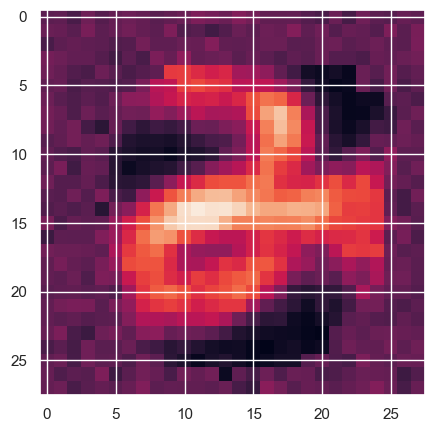

In [30]:
plt.imshow(decoded.reshape(10, 10, 28, 28)[0, 4])

In [31]:
# styles = torch.Tensor(
#     np.concatenate([
#         np.concatenate([np.linspace(-3., 3., 5).reshape(5, 1), np.zeros(shape=(5, 1))], axis=1),
#         np.concatenate([np.zeros(shape=(5, 1)), np.linspace(-3., 3., 5).reshape(5, 1)], axis=1),
#     ], axis=0)
# )

# Create 10 style vectors, each 10-dimensional
styles = torch.cat([
    torch.cat([torch.linspace(-3., 3., 5).reshape(5,1),
               torch.zeros(5,9)], dim=1),
    torch.cat([torch.zeros(5,9),
               torch.linspace(-3., 3., 5).reshape(5,1)], dim=1)
], dim=0)


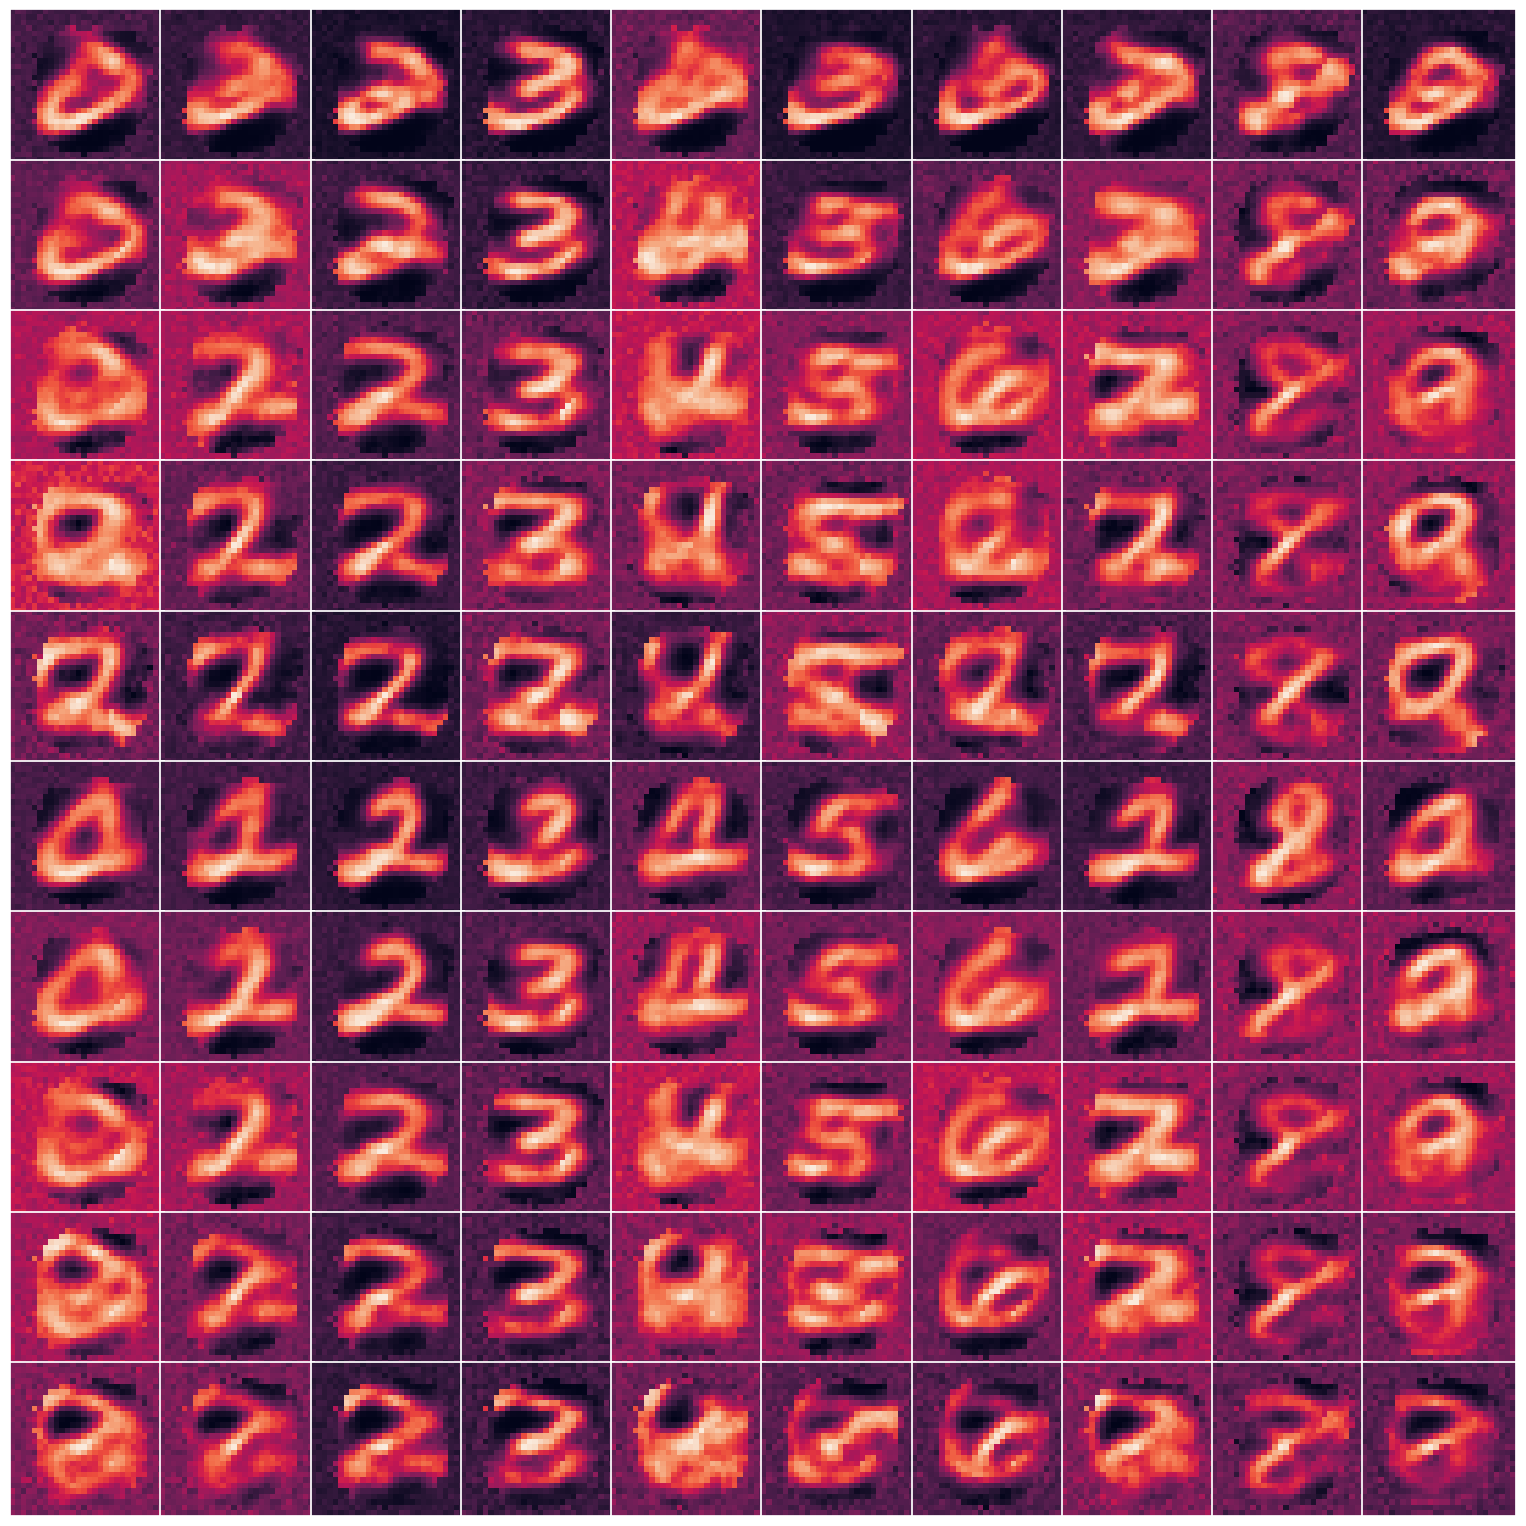

In [32]:
import random

nrows = styles.shape[0]
ncols = 10
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15 * nrows / 10))
numbers = torch.Tensor(np.eye(10))
for row, style in enumerate(styles):
    for col, number in enumerate(numbers):
        coded = torch.cat([number, style], -1).to(device)
        decoded = decoder(coded).cpu().data.numpy()
        ax = axes[row, col]
        ax.imshow(decoded.reshape(28, 28))
        ax.grid(False)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

fig.tight_layout(pad=-.2)

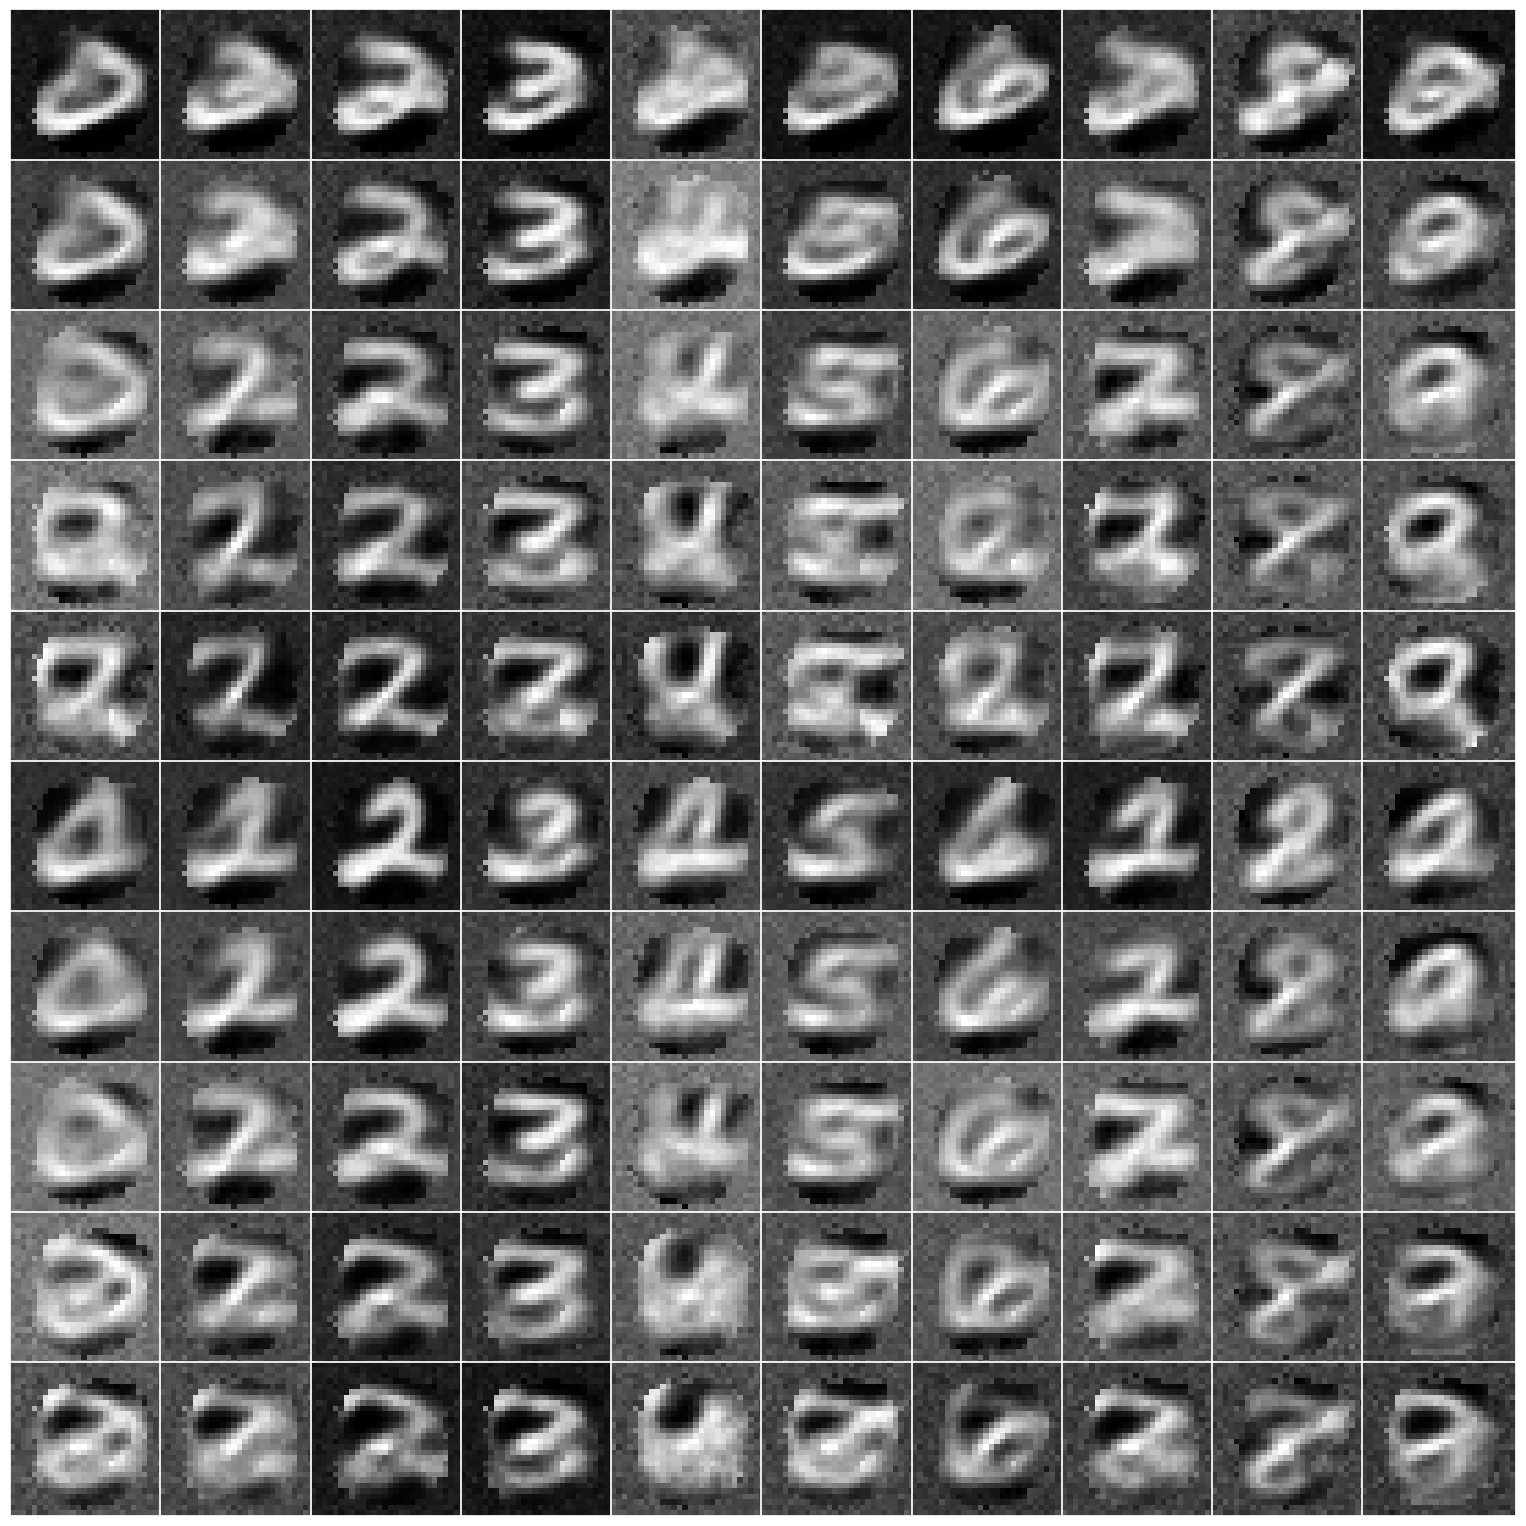

In [33]:
import random

nrows = styles.shape[0]   # number of style vectors
ncols = 10                # 10 classes

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 15 * nrows / 10))

numbers = torch.Tensor(np.eye(10))   # one-hot labels

for row, style in enumerate(styles):
    for col, number in enumerate(numbers):

        # concatenate class label + style vector
        coded = torch.cat([number, style], -1).unsqueeze(0).to(device)

        # decode
        decoded = decoder(coded).cpu().data.numpy()[0]

        # plot
        ax = axes[row, col]
        ax.imshow(decoded.reshape(28, 28), cmap='gray')
        ax.grid(False)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

fig.tight_layout(pad=-.2)
plt.show()
